# Machine Learning Volatility Forecasting

This notebook enhances the statistical risk engine using
machine learning models.

Models used:
- Linear Regression
- Random Forest

The models predict next-day realized volatility using:

- Lagged returns
- Squared returns
- Rolling volatility
- EWMA volatility

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.risk_metrics import compute_log_returns, rolling_volatility, ewma_volatility
from src.ml_models import prepare_ml_dataset, train_models

In [2]:
assets = ["AAPL", "MSFT", "SPY", "BTC-USD", "GLD"]
start_date = "2015-01-01"

prices = pd.DataFrame()

for ticker in assets:
    data = yf.download(ticker, start=start_date, progress=False)
    prices[ticker] = data["Close"][ticker]

prices.dropna(inplace=True)

In [3]:
returns = compute_log_returns(prices)
rolling_vol = rolling_volatility(returns)
ewma_vol = ewma_volatility(returns)

In [4]:
asset = "BTC-USD"

df_ml = prepare_ml_dataset(asset, returns, rolling_vol, ewma_vol)

rmse_lr, rmse_rf, test_index = train_models(df_ml)

print("Linear RMSE:", rmse_lr)
print("Random Forest RMSE:", rmse_rf)

Linear RMSE: 0.03177774427741562
Random Forest RMSE: 0.03544068706913219


In [5]:
results = []

for asset in returns.columns:
    
    df_ml = prepare_ml_dataset(asset, returns, rolling_vol, ewma_vol)
    rmse_lr, rmse_rf, test_index = train_models(df_ml)

    results.append({
        "Asset": asset,
        "Linear RMSE": rmse_lr,
        "Random Forest RMSE": rmse_rf
    })

results_df = pd.DataFrame(results)
results_df

,Asset,Linear RMSE,Random Forest RMSE
0,AAPL,0.022673,0.024740
1,MSFT,0.020183,0.020892
2,SPY,0.013792,0.013358
3,BTC-USD,0.031778,0.035441
4,GLD,0.016611,0.038652


In [6]:
results = []

for asset in returns.columns:
    
    df_ml = prepare_ml_dataset(asset, returns, rolling_vol, ewma_vol)
    rmse_lr, rmse_rf, test_index = train_models(df_ml)

    results.append({
        "Asset": asset,
        "Linear RMSE": rmse_lr,
        "Random Forest RMSE": rmse_rf
    })

results_df = pd.DataFrame(results)
results_df

,Asset,Linear RMSE,Random Forest RMSE
0,AAPL,0.022673,0.024740
1,MSFT,0.020183,0.020892
2,SPY,0.013792,0.013358
3,BTC-USD,0.031778,0.035441
4,GLD,0.016611,0.038652


In [7]:
final_forecasts = []

for asset in returns.columns:
    
    df_ml = prepare_ml_dataset(asset, returns, rolling_vol, ewma_vol)
    
    X = df_ml.drop(columns=["target"])
    y = df_ml["target"]
    
    from sklearn.linear_model import LinearRegression
    
    model = LinearRegression()
    model.fit(X, y)
    
    last_features = X.iloc[-1:]
    forecast = model.predict(last_features)[0]
    
    final_forecasts.append({
        "Asset": asset,
        "Forecasted Volatility": forecast
    })

forecast_df = pd.DataFrame(final_forecasts)
forecast_df

,Asset,Forecasted Volatility
0,AAPL,0.297948
1,MSFT,0.323522
2,SPY,0.131151
3,BTC-USD,0.818458
4,GLD,0.413291


In [13]:
from src.risk_metrics import ewma_covariance, portfolio_volatility

cov_matrices = ewma_covariance(returns)
latest_cov = cov_matrices[-1]

weights = np.ones(len(returns.columns)) / len(returns.columns)

portfolio_vol = portfolio_volatility(latest_cov, weights)

print("Forecasted Portfolio Volatility:", portfolio_vol)
print("Forecasted Portfolio Volatility:", round(portfolio_vol, 4))
print("Number of Assets:", len(returns.columns))
print("Portfolio Weights: Equal Weight")

Forecasted Portfolio Volatility: 0.22765706988306142
Forecasted Portfolio Volatility: 0.2277
Number of Assets: 5
Portfolio Weights: Equal Weight


In [10]:
results = []

for asset in returns.columns:

    df_ml = prepare_ml_dataset(asset, returns, rolling_vol, ewma_vol)

    rmse_lr, rmse_rf, _ = train_models(df_ml)

    results.append({
        "Asset": asset,
        "Linear RMSE": rmse_lr,
        "Random Forest RMSE": rmse_rf
    })

results_df = pd.DataFrame(results)
results_df


,Asset,Linear RMSE,Random Forest RMSE
0,AAPL,0.022673,0.024740
1,MSFT,0.020183,0.020892
2,SPY,0.013792,0.013358
3,BTC-USD,0.031778,0.035441
4,GLD,0.016611,0.038652


In [11]:
final_forecasts = []

for asset in returns.columns:
    
    realized_vol = returns[asset].rolling(21).std().shift(-1) * np.sqrt(252)
    
    df_ml = pd.DataFrame()
    df_ml["return"] = returns[asset]
    df_ml["return_lag1"] = returns[asset].shift(1)
    df_ml["return_sq_lag1"] = returns[asset].shift(1)**2
    df_ml["rolling_vol"] = rolling_vol[asset]
    df_ml["ewma_vol"] = ewma_vol[asset]
    df_ml["target"] = realized_vol
    
    df_ml = df_ml.dropna()
    
    X = df_ml.drop(columns=["target"])
    y = df_ml["target"]
    
    model = LinearRegression()
    model.fit(X, y)
    
    last_features = X.iloc[-1:]
    
    forecast = model.predict(last_features)[0]
    
    final_forecasts.append({
        "Asset": asset,
        "Forecasted Volatility (Annualized)": forecast
    })

forecast_df = pd.DataFrame(final_forecasts)
forecast_df


,Asset,Forecasted Volatility (Annualized)
0,AAPL,0.297948
1,MSFT,0.323522
2,SPY,0.131151
3,BTC-USD,0.818458
4,GLD,0.413291


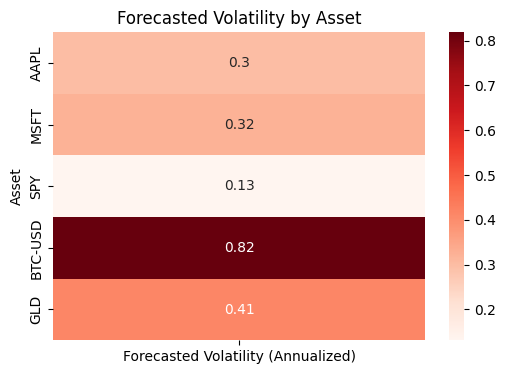

In [12]:
import seaborn as sns

heatmap_data = forecast_df.set_index("Asset")

plt.figure(figsize=(6,4))
sns.heatmap(heatmap_data, annot=True, cmap="Reds")
plt.title("Forecasted Volatility by Asset")
plt.show()

# Final Risk Engine Output

The system forecasts forward-looking volatility for each asset
using machine learning models trained on rolling volatility,
EWMA volatility, and lagged return features.

These forecasts are combined with EWMA covariance estimates
to produce a forward-looking portfolio volatility estimate.